# Agricultural Performance and Seasonal Analysis Using Data Analytics

**Dataset:** Crop Yield in Indian States (Kaggle) — `crop_yield.csv`
**Source:** https://www.kaggle.com/datasets/akshatgupta7/crop-yield-in-indian-states-dataset/versions/1
**Coverage:** 1997–2020, 55 crops, 30 states, 6 seasons

This notebook follows a **Raw Data → Information → Insights → Decision → Action** analytics framework to analyze
agricultural production, yield, seasonal patterns, and the relationship between environmental/input factors and yield,
concluding with actionable recommendations.

## Table of Contents
1. Setup & Data Loading
2. Data Quality Checks
3. Data Cleaning & Preprocessing
4. KPI Analysis (Executive Overview)
5. Yearly Production & Yield Trends
6. Crop Performance Analysis
7. State / Regional Performance Analysis
8. Seasonal Analysis
9. Rainfall, Fertilizer & Pesticide vs Yield
10. Risks, Opportunities & Recommendations
11. Conclusion


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10.5,
    "axes.titlesize": 12.5,
    "axes.titleweight": "bold",
})

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
df_raw = pd.read_csv("crop_yield.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,"73,814.00",56708,"2,051.40","7,024,878.38","22,882.34",0.80
1,Arhar/Tur,1997,Kharif,Assam,"6,637.00",4685,"2,051.40","631,643.29","2,057.47",0.71
2,Castor seed,1997,Kharif,Assam,796.00,22,"2,051.40","75,755.32",246.76,0.24
3,Coconut,1997,Whole Year,Assam,"19,656.00",126905000,"2,051.40","1,870,661.52","6,093.36","5,238.05"
4,Cotton(lint),1997,Kharif,Assam,"1,739.00",794,"2,051.40","165,500.63",539.09,0.42


## 2. Data Quality Checks

Before any analysis we check for missing values, duplicate rows, data types, and category label
consistency (trailing whitespace is known to exist in `Crop`, `Season`, and `State`).

In [3]:
print("Data types:\n", df_raw.dtypes)
print("\nMissing values per column:\n", df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())


Data types:
 Crop                   str
Crop_Year            int64
Season                 str
State                  str
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

Missing values per column:
 Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

Duplicate rows: 0


In [4]:
# Inspect whitespace issue
print("Example raw category values (repr shows hidden whitespace):")
print(df_raw['Season'].unique()[:6])
print(df_raw['Crop'].unique()[:3])


Example raw category values (repr shows hidden whitespace):
<StringArray>
['Whole Year ', 'Kharif     ', 'Rabi       ', 'Autumn     ', 'Summer     ',
 'Winter     ']
Length: 6, dtype: str
<StringArray>
['Arecanut', 'Arhar/Tur', 'Castor seed']
Length: 3, dtype: str


## 3. Data Cleaning & Preprocessing

**Cleaning steps applied:**
1. Strip leading/trailing whitespace from `Crop`, `Season`, `State`.
2. Investigate (not blindly remove) records with `Production == 0`.
3. Investigate extreme/large `Production` values before deciding whether to treat them as valid.
4. Flag 2020 as a **partial year** (only a small number of records) so it is never presented as a complete
   annual trend.


In [5]:
df = df_raw.copy()
for c in ["Crop", "Season", "State"]:
    df[c] = df[c].astype(str).str.strip()

print("Crops:", df['Crop'].nunique(), "| States:", df['State'].nunique(), "| Seasons:", df['Season'].nunique())
print("Seasons:", sorted(df['Season'].unique()))
print("Year range:", df['Crop_Year'].min(), "-", df['Crop_Year'].max())
print("Rows in 2020 (partial year):", (df['Crop_Year']==2020).sum())


Crops: 55 | States: 30 | Seasons: 6
Seasons: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']
Year range: 1997 - 2020
Rows in 2020 (partial year): 37


### 3.1 Investigating zero-production records

Rather than deleting these rows, we examine which crops/states/seasons they belong to. Zero production with
non-zero cultivated area is consistent with a **failed harvest** (drought, flood, pest attack, or crop
abandonment) in that crop-year-state-season combination, which is legitimate agronomic information, not a
data error. These rows are **kept** for area/production/risk-related analysis, but are **excluded only from
yield-based averages**, since a `Yield = 0` observation would otherwise distort "typical yield achieved"
statistics without adding meaningful information about attainable yield.

In [6]:
zero_prod = df[df['Production'] == 0]
print(f"Zero-production rows: {len(zero_prod)} ({100*len(zero_prod)/len(df):.2f}% of data)")
print("\nTop states with zero-production records:")
print(zero_prod['State'].value_counts().head(5))
print("\nTop crops with zero-production records:")
print(zero_prod['Crop'].value_counts().head(5))


Zero-production rows: 112 (0.57% of data)

Top states with zero-production records:
State
Haryana           27
Chhattisgarh      22
Kerala            21
Andhra Pradesh    13
Tamil Nadu        10
Name: count, dtype: int64

Top crops with zero-production records:
Crop
Jute          15
Sannhamp       7
Horse-gram     7
Onion          7
Coconut        7
Name: count, dtype: int64


### 3.2 Investigating extreme production values

The largest `Production` values all belong to **Coconut**. This is not a data error — coconut production in
this dataset is recorded as a **nut count**, not tonnes, unlike most other crops which are recorded in
tonnes/quintals. This unit difference legitimately produces values that are orders of magnitude larger than
other crops and must be accounted for in analysis (e.g., excluding coconut from cross-crop yield comparisons
on a shared axis, or noting the unit difference explicitly).

In [7]:
top5 = df.sort_values('Production', ascending=False).head(5)[['Crop','Crop_Year','State','Production','Yield']]
top5


,Crop,Crop_Year,State,Production,Yield
1822,Coconut,2005,Kerala,6326000000,"6,500.86"
3572,Coconut,2011,Tamil Nadu,6200900000,"13,248.16"
2141,Coconut,2006,Kerala,6054000000,"6,522.32"
1584,Coconut,2004,Kerala,6001000000,"6,112.15"
4692,Coconut,2015,Tamil Nadu,5962500000,"11,907.65"


In [8]:
# Decision: keep zero-production rows (valid for area/risk analysis) and keep extreme coconut values
# (valid, different unit). Create a yield-safe frame that excludes zero-production rows only for
# yield-based aggregation, and flag 2020 as partial.
df_for_yield = df[df['Production'] > 0].copy()
df['is_2020_partial'] = df['Crop_Year'] == 2020
print("Rows retained for yield-based analysis:", len(df_for_yield), "of", len(df))


Rows retained for yield-based analysis: 19577 of 19689


## 4. KPI Analysis (Executive Overview)

Core KPIs computed across the full cleaned dataset (1997–2020, including the partial 2020 records for
totals; yield-based KPI uses the yield-safe frame).

In [9]:
kpi = {
    "Total Production (reported units)": df["Production"].sum(),
    "Average Yield (yield-safe)": df_for_yield["Yield"].mean(),
    "Total Cultivated Area (ha)": df["Area"].sum(),
    "Average Annual Rainfall (mm)": df["Annual_Rainfall"].mean(),
    "Total Fertilizer Usage (kg)": df["Fertilizer"].sum(),
    "Total Pesticide Usage (kg)": df["Pesticide"].sum(),
    "Number of Crops": df["Crop"].nunique(),
    "Number of States": df["State"].nunique(),
}
for k, v in kpi.items():
    print(f"{k:38s}: {v:,.2f}" if isinstance(v,(int,float)) else f"{k}: {v}")


Total Production (reported units): 323607247726
Average Yield (yield-safe)            : 80.41
Total Cultivated Area (ha)            : 3,542,574,242.80
Average Annual Rainfall (mm)          : 1,437.76
Total Fertilizer Usage (kg)           : 474,570,118,804.54
Total Pesticide Usage (kg)            : 961,775,229.94
Number of Crops                       : 55.00
Number of States                      : 30.00


## 5. Yearly Production & Yield Trends

**Note:** 2020 is excluded from the annual trend chart and growth-rate calculation because it contains only
a small number of records and does not represent a complete year of data.

In [10]:
df_trend = df[df['Crop_Year'] < 2020]
yearly = df_trend.groupby('Crop_Year').agg(Total_Production=('Production','sum'),
                                            Total_Area=('Area','sum')).reset_index()
yearly_yield = df_for_yield[df_for_yield['Crop_Year']<2020].groupby('Crop_Year')['Yield'].mean().reset_index()
yearly = yearly.merge(yearly_yield, on='Crop_Year', how='left')

prod_growth = 100*(yearly['Total_Production'].iloc[-1]-yearly['Total_Production'].iloc[0])/yearly['Total_Production'].iloc[0]
area_growth = 100*(yearly['Total_Area'].iloc[-1]-yearly['Total_Area'].iloc[0])/yearly['Total_Area'].iloc[0]
print(f"Production change 1997->2019: {prod_growth:.1f}%")
print(f"Cultivated area change 1997->2019: {area_growth:.1f}%")


Production change 1997->2019: 200.2%
Cultivated area change 1997->2019: 1.8%


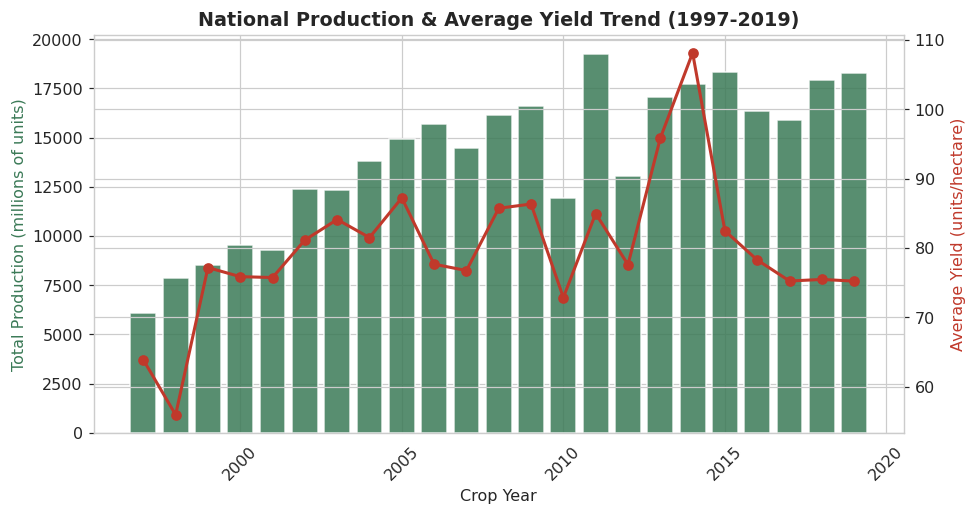

In [11]:
fig, ax1 = plt.subplots(figsize=(9,4.8))
ax1.bar(yearly['Crop_Year'], yearly['Total_Production']/1e6, color='#3b7a57', alpha=0.85)
ax1.set_xlabel('Crop Year'); ax1.set_ylabel('Total Production (millions of units)', color='#3b7a57')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(yearly['Crop_Year'], yearly['Yield'], color='#c0392b', marker='o', linewidth=2)
ax2.set_ylabel('Average Yield (units/hectare)', color='#c0392b')
plt.title('National Production & Average Yield Trend (1997-2019)')
fig.tight_layout()
plt.show()


**Interpretation:** Total reported production rose substantially over the period while cultivated area
stayed comparatively flat, indicating the increase is largely driven by yield/productivity gains and a shift
in crop mix (especially high-volume crops like coconut and sugarcane) rather than by land expansion. Year to
year yield is volatile, consistent with weather-driven variability rather than a smooth trend.

## 6. Crop Performance Analysis

To avoid noise from crops with very few records, "top yield" rankings use only crops with **at least 20
records** in the yield-safe dataset.

In [12]:
crop_stats = df_for_yield.groupby('Crop').agg(Total_Production=('Production','sum'),
                                                Avg_Yield=('Yield','mean'),
                                                Total_Area=('Area','sum'),
                                                Records=('Crop','count')).reset_index()
crop_reliable = crop_stats[crop_stats['Records'] >= 20]

top_prod_crops = crop_stats.sort_values('Total_Production', ascending=False).head(10)
top_yield_crops = crop_reliable.sort_values('Avg_Yield', ascending=False).head(10)
low_yield_crops = crop_reliable.sort_values('Avg_Yield', ascending=True).head(10)

top_prod_crops[['Crop','Total_Production']]


,Crop,Total_Production
9,Coconut,308751970278
46,Sugarcane,7236536755
40,Rice,2229301180
53,Wheat,1810754504
37,Potato,629688035
11,Cotton(lint),457831414
24,Maize,410911181
21,Jute,230423821
3,Banana,226471979
45,Soyabean,191659664


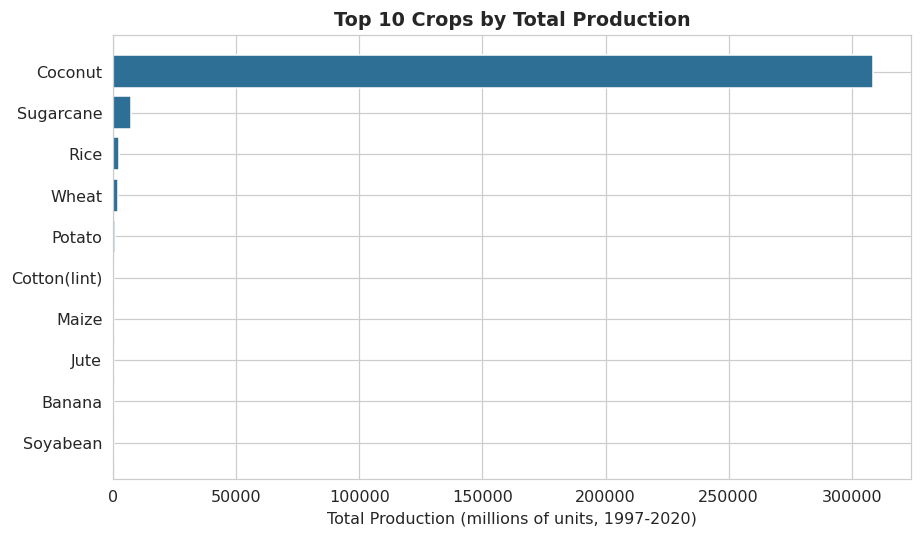

In [13]:
fig, ax = plt.subplots(figsize=(8.5,5))
d = top_prod_crops.sort_values('Total_Production')
ax.barh(d['Crop'], d['Total_Production']/1e6, color='#2e6f95')
ax.set_xlabel('Total Production (millions of units, 1997-2020)')
ax.set_title('Top 10 Crops by Total Production')
plt.tight_layout(); plt.show()


**Interpretation:** Coconut dominates total production by a wide margin, but this is largely a unit-scale
effect (nut count vs. tonnes) rather than proof it is the most economically dominant crop. Rice, wheat and
sugarcane — India's staple/cash crops — follow as the next largest by reported volume.

In [14]:
top_yield_crops[['Crop','Avg_Yield','Records']]


,Crop,Avg_Yield,Records
9,Coconut,"9,019.05",165
46,Sugarcane,51.73,605
3,Banana,27.07,243
49,Tapioca,16.75,200
31,Onion,13.45,447
37,Potato,13.35,627
48,Sweet potato,9.41,268
21,Jute,8.24,166
15,Ginger,6.48,321
26,Mesta,5.47,207


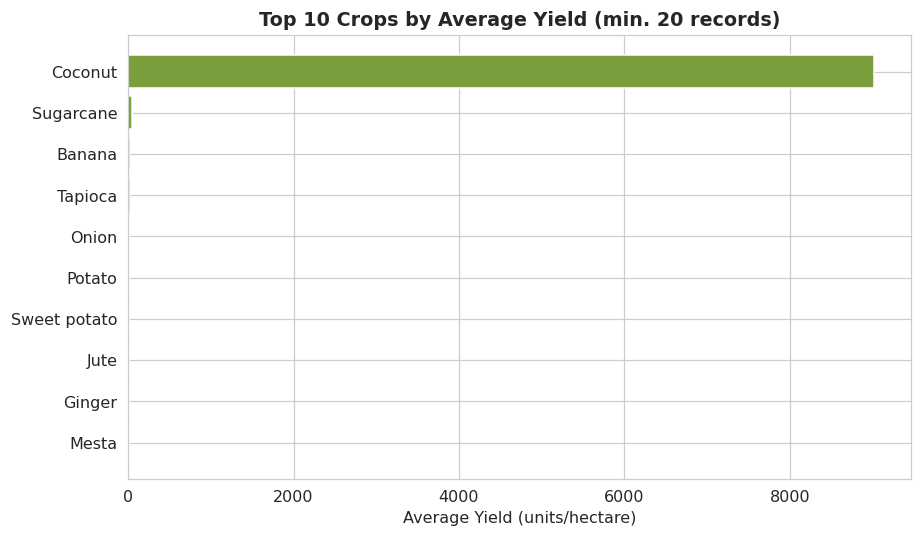

In [15]:
fig, ax = plt.subplots(figsize=(8.5,5))
d = top_yield_crops.sort_values('Avg_Yield')
ax.barh(d['Crop'], d['Avg_Yield'], color='#7a9e3b')
ax.set_xlabel('Average Yield (units/hectare)')
ax.set_title('Top 10 Crops by Average Yield (min. 20 records)')
plt.tight_layout(); plt.show()


**Interpretation:** Coconut's yield figure is likewise inflated by its count-based unit and should not be
compared directly against tonnage-based crops like sugarcane or banana. Excluding the unit outlier,
sugarcane, banana and tapioca show the strongest yield performance among reliably sampled crops. At the
other end, oilseed and pulse crops (Cardamom, Niger seed, Moth, Horse-gram) show the lowest average yields,
which is expected agronomically since these are typically low-yield-per-hectare, rainfed crops.

## 7. State / Regional Performance Analysis

In [16]:
state_stats = df_for_yield.groupby('State').agg(Total_Production=('Production','sum'),
                                                   Avg_Yield=('Yield','mean'),
                                                   Total_Area=('Area','sum'),
                                                   Records=('State','count')).reset_index()
top_states_prod = state_stats.sort_values('Total_Production', ascending=False).head(10)
top_states_prod[['State','Total_Production']]


,State,Total_Production
13,Kerala,129700649853
24,Tamil Nadu,78051759253
12,Karnataka,63772797366
0,Andhra Pradesh,26076218605
29,West Bengal,8941179120
27,Uttar Pradesh,4442585302
2,Assam,3637714928
6,Goa,2193998349
15,Maharashtra,1878564915
14,Madhya Pradesh,834490323


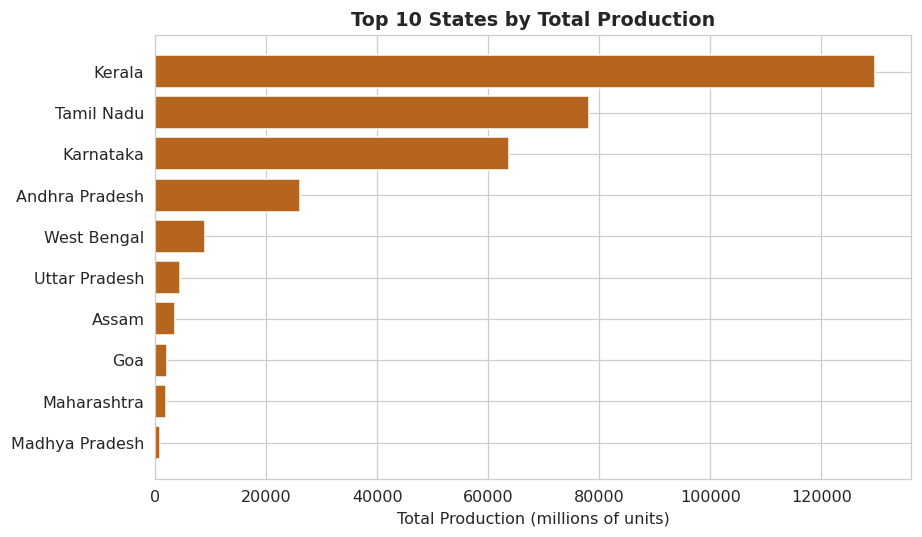

In [17]:
fig, ax = plt.subplots(figsize=(8.5,5))
d = top_states_prod.sort_values('Total_Production')
ax.barh(d['State'], d['Total_Production']/1e6, color='#b5651d')
ax.set_xlabel('Total Production (millions of units)')
ax.set_title('Top 10 States by Total Production')
plt.tight_layout(); plt.show()


**Interpretation:** Kerala, Tamil Nadu and Karnataka lead national production totals, again heavily
influenced by their large coconut output. Excluding this unit effect, Uttar Pradesh, West Bengal, and Andhra
Pradesh remain major contributors driven by rice, wheat and sugarcane.

In [18]:
state_reliable = state_stats[state_stats['Records']>=20]
bottom_states_yield = state_reliable.sort_values('Avg_Yield', ascending=True).head(10)
bottom_states_yield[['State','Avg_Yield']]


,State,Avg_Yield
23,Sikkim,1.23
10,Jammu and Kashmir,1.31
9,Himachal Pradesh,1.90
4,Chhattisgarh,2.02
18,Mizoram,2.57
17,Meghalaya,2.88
20,Odisha,3.14
19,Nagaland,3.40
14,Madhya Pradesh,3.47
3,Bihar,3.48


**Interpretation:** States such as Sikkim, Jammu & Kashmir, Himachal Pradesh, Chhattisgarh and Odisha show
the lowest average yields among reliably sampled states — consistent with hilly/rainfed terrain, smaller
mechanized-farming penetration, and crop-mix differences (more low-yield pulses/millets) rather than
necessarily poorer farming practice.

## 8. Seasonal Analysis

In [19]:
season_stats = df_for_yield.groupby('Season').agg(Total_Production=('Production','sum'),
                                                     Avg_Yield=('Yield','mean'),
                                                     Total_Area=('Area','sum'),
                                                     Records=('Season','count')).reset_index()
season_stats.sort_values('Total_Production', ascending=False)


,Season,Total_Production,Avg_Yield,Total_Area,Records
4,Whole Year,314452748974,418.51,"229,031,007.28",3668
1,Kharif,5402484780,2.50,"1,702,479,306.76",8181
2,Rabi,2837368229,1.99,"1,172,569,901.01",5732
5,Winter,586507936,5.29,"280,684,654.63",389
3,Summer,243731156,3.00,"98,790,963.92",1193
0,Autumn,84406651,3.92,"58,626,370.49",414


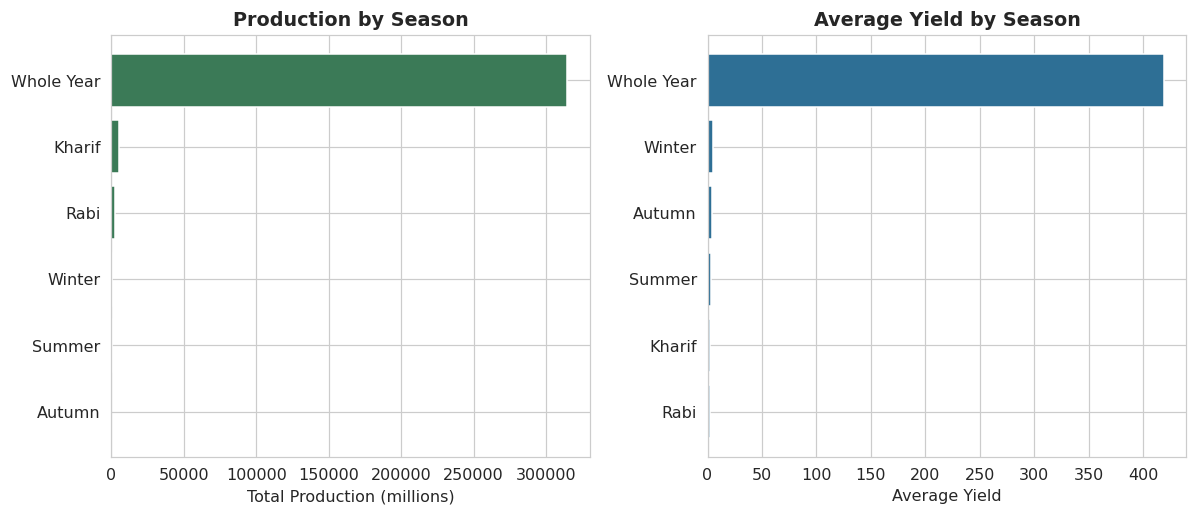

In [20]:
fig, axes = plt.subplots(1,2, figsize=(11,4.8))
d = season_stats.sort_values('Total_Production')
axes[0].barh(d['Season'], d['Total_Production']/1e6, color='#3b7a57')
axes[0].set_xlabel('Total Production (millions)'); axes[0].set_title('Production by Season')
d2 = season_stats.sort_values('Avg_Yield')
axes[1].barh(d2['Season'], d2['Avg_Yield'], color='#2e6f95')
axes[1].set_xlabel('Average Yield'); axes[1].set_title('Average Yield by Season')
plt.tight_layout(); plt.show()


**Interpretation:** The `Whole Year` season category shows by far the highest average yield and a large
share of total production — this is expected since perennial crops (coconut, sugarcane, banana) are recorded
under `Whole Year` and are harvested continuously rather than in a single cropping window. `Kharif` (monsoon
season) accounts for the largest cultivated **area**, reflecting India's monsoon-dependent cropping calendar,
while `Rabi` (winter season) is the second largest. `Autumn`, `Summer` and `Winter` are comparatively minor
cropping windows in this dataset.

## 9. Rainfall, Fertilizer & Pesticide vs Yield

**Important:** the following are *correlation* statistics only. A weak or moderate correlation does **not**
establish causation, and these variables interact with many un-modeled factors (soil quality, irrigation
access, crop variety, farm management practices, price incentives, etc.).

Fertilizer and pesticide are also converted to a **per-hectare** basis before correlating with yield, since
their raw totals scale mechanically with cultivated area (a bigger farm naturally uses more total fertilizer)
and comparing raw totals to a per-hectare yield metric would be an apples-to-oranges comparison.

In [21]:
corr_rain = df_for_yield['Annual_Rainfall'].corr(df_for_yield['Yield'])

df_for_yield['Fert_per_ha'] = df_for_yield['Fertilizer'] / df_for_yield['Area']
df_for_yield['Pest_per_ha'] = df_for_yield['Pesticide'] / df_for_yield['Area']
corr_fert_ha = df_for_yield['Fert_per_ha'].corr(df_for_yield['Yield'])
corr_pest_ha = df_for_yield['Pest_per_ha'].corr(df_for_yield['Yield'])

print(f"Correlation (Annual Rainfall vs Yield):        r = {corr_rain:.4f}")
print(f"Correlation (Fertilizer/ha vs Yield):          r = {corr_fert_ha:.4f}")
print(f"Correlation (Pesticide/ha vs Yield):           r = {corr_pest_ha:.4f}")


Correlation (Annual Rainfall vs Yield):        r = 0.0208
Correlation (Fertilizer/ha vs Yield):          r = 0.0020
Correlation (Pesticide/ha vs Yield):           r = -0.0015


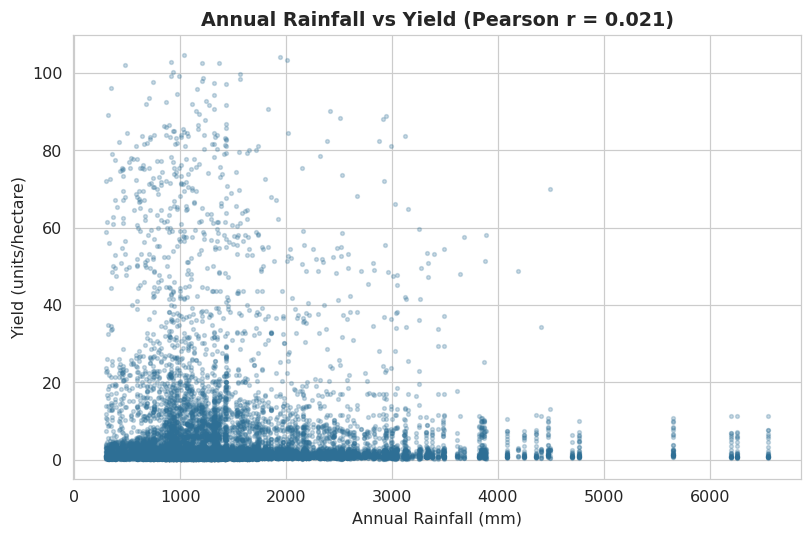

In [22]:
# Clip to 1st-99th percentile of Yield purely for visualization clarity (does not affect the correlation above)
q_low, q_high = df_for_yield['Yield'].quantile([0.01, 0.99])
plot_df = df_for_yield[(df_for_yield['Yield']>=q_low) & (df_for_yield['Yield']<=q_high)]

fig, ax = plt.subplots(figsize=(7.5,5))
ax.scatter(plot_df['Annual_Rainfall'], plot_df['Yield'], s=6, alpha=0.25, color='#2e6f95')
ax.set_xlabel('Annual Rainfall (mm)'); ax.set_ylabel('Yield (units/hectare)')
ax.set_title(f'Annual Rainfall vs Yield (Pearson r = {corr_rain:.3f})')
plt.tight_layout(); plt.show()


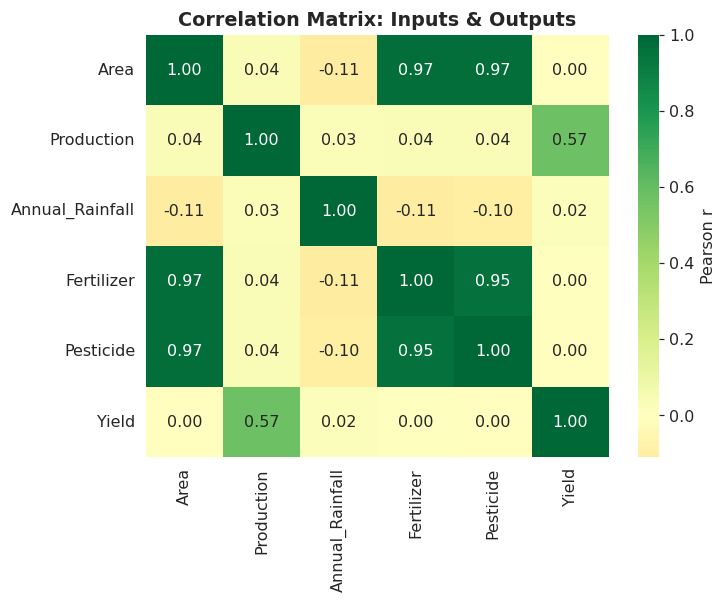

In [23]:
corr_cols = ['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']
corr_matrix = df_for_yield[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6.8,5.6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label':'Pearson r'})
ax.set_title('Correlation Matrix: Inputs & Outputs')
plt.tight_layout(); plt.show()


**Interpretation:** Across the full dataset, rainfall, fertilizer-per-hectare and pesticide-per-hectare all
show **near-zero linear correlation with yield** at the national, all-crop level. This does **not** mean
rainfall or fertilizer are unimportant to farming — it means their effect is masked at this aggregate,
cross-crop level by the fact that different crops have vastly different yield scales and input needs (e.g.
comparing a rainfed pulse to an irrigated cash crop in one pooled correlation). The correlation matrix also
shows `Area`, `Fertilizer` and `Pesticide` are very strongly correlated with **each other** (r ≈ 0.95–0.97) —
this is expected, since larger cultivated area mechanically requires more total fertilizer and pesticide, and
this collinearity is exactly why per-hectare (intensity) figures are used above rather than raw totals when
relating inputs to yield. A crop-specific or region-specific regression would be needed to isolate a genuine
input-yield relationship; that is outside the scope of this descriptive analysis and is noted as a
limitation.

## 10. Risks, Opportunities & Recommended Actions

Rainfall variability by state is used as a simple proxy for regional weather risk.

In [24]:
rain_by_state = df.groupby('State')['Annual_Rainfall'].agg(['mean','std']).reset_index()
rain_by_state['cv'] = rain_by_state['std'] / rain_by_state['mean']
rain_by_state.sort_values('cv', ascending=False).head(5)


,State,mean,std,cv
7,Gujarat,784.80,223.48,0.28
17,Meghalaya,"4,043.08","1,116.89",0.28
16,Manipur,"1,546.95",398.17,0.26
8,Haryana,466.91,119.01,0.25
24,Tamil Nadu,931.16,233.72,0.25


### Risks
- **Rainfall dependence in Kharif season:** the largest cropping window by area is monsoon-dependent, exposing
  a large share of cultivated area to weather risk.
- **Zero-yield/crop-failure incidents:** 112 crop-year-state-season records report zero production despite
  non-zero cultivated area — concentrated in states like Haryana, Chhattisgarh and Kerala, and crops like
  Jute, Sannhamp and Horse-gram — indicating localized harvest failures worth monitoring.
- **High rainfall variability states** (Gujarat, Meghalaya, Manipur, Haryana, Tamil Nadu by coefficient of
  variation) face higher year-to-year weather-driven production risk.
- **Low-yield states** in hilly/rainfed regions (Sikkim, J&K, Himachal Pradesh, Chhattisgarh, Odisha) show
  structurally low productivity that a single national policy is unlikely to fix.

### Opportunities
- **Yield-driven growth path:** since cultivated area has grown only marginally while production has grown
  much faster, continued investment in yield-improving practices (irrigation, better seed varieties, soil
  management) — not land expansion — is the fertile lever to pursue.
- **High-yield crop diversification:** sugarcane, banana and tapioca show strong reliable yields and could be
  promoted (where agro-climatically suitable) in lower-yield states currently dominated by low-yield pulses.
- **Targeted input-efficiency programs:** because fertilizer/pesticide use shows negligible correlation with
  yield at the aggregate level, there is an opportunity to audit input efficiency crop-by-crop rather than
  assuming "more input = more yield," potentially reducing costs without a yield penalty.

### Actionable Recommendations
1. Prioritize **irrigation and water-management investment** in Kharif-heavy, high rainfall-variability states
   (e.g. Gujarat, Haryana, Tamil Nadu) to reduce weather-driven production risk.
2. Conduct **crop-specific (not pooled) regression/agronomic studies** on fertilizer and pesticide efficiency,
   since the pooled correlation is uninformative and risks over- or under-investment if applied uniformly.
3. Investigate the **recurring zero-production incidents** in the identified state-crop combinations for root
   cause (pest, drought, or policy/market withdrawal) and build early-warning support for those regions.
4. Treat **coconut and other count-based-unit crops separately** in any dashboard or KPI that aggregates
   production/yield across crops, to avoid misleading headline numbers.
5. Exclude or clearly flag **2020** in any year-over-year reporting, since it is a partial year in this
   dataset.


## 11. Conclusion

Between 1997 and 2019, India's reported agricultural production grew markedly while cultivated area remained
comparatively flat, indicating productivity-led growth. Coconut dominates raw production/yield totals largely
due to its distinct count-based unit rather than genuine cross-crop superiority. Seasonal analysis shows
`Kharif` as the dominant cropping window by area and `Whole Year` (perennial) crops as the highest-yielding
category. At the aggregate level, rainfall, fertilizer and pesticide show negligible linear correlation with
yield — a finding that should be read as a call for **crop- and region-specific analysis**, not evidence that
these inputs do not matter. The state and crop rankings, and the zero-production and rainfall-variability
findings, point to concrete, targeted opportunities for irrigation investment, input-efficiency auditing, and
risk monitoring rather than one-size-fits-all national interventions.

**Limitations:** This is a descriptive/correlational analysis of secondary, state-reported data; it does not
control for soil quality, irrigation access, farm size, market prices, or crop variety, and 2020 is
incomplete. Correlation coefficients reported here must not be interpreted as causal effects.
